# Predicting HDB Resale Flat Prices in Singapore using Graph NN

This notebook constructs the HDB resale graph and trains GraphSAGE embeddings.

# 1. Imports

In [2]:
import os
import re
import gc
from math import radians, cos, sin, asin, sqrt
from itertools import combinations
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge

import xgboost as xgb
from xgboost import XGBRegressor

import networkx as nx
from adjustText import adjust_text

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

import joblib

# 2. Constructing Graph to represent resale data

In [3]:
#helper function for haversine distance 
def haversine(coord1, coord2):
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    R = 6371  # km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c
    
#hardcoded coords from wiki
town_coords = {
    "ANG MO KIO": (1.37, 103.84),
    "BEDOK": (1.32, 103.94),
    "BISHAN": (1.35, 103.85),
    "BUKIT BATOK": (1.35, 103.75),
    "BUKIT MERAH": (1.28, 103.82),
    "BUKIT PANJANG": (1.38, 103.77),
    "BUKIT TIMAH": (1.34, 103.78),
    "CENTRAL AREA": (1.29, 103.85),
    "CHOA CHU KANG": (1.38, 103.74),
    "CLEMENTI": (1.31, 103.77),
    "GEYLANG": (1.32, 103.88),
    "HOUGANG": (1.37, 103.89),
    "JURONG EAST": (1.33, 103.74),
    "JURONG WEST": (1.34, 103.70),
    "KALLANG/WHAMPOA": (1.32, 103.86),
    "LIM CHU KANG": (1.44, 103.72),
    "MARINE PARADE": (1.30, 103.91),
    "PASIR RIS": (1.37, 103.95),
    "PUNGGOL": (1.40, 103.91),
    "QUEENSTOWN": (1.30, 103.80),
    "SEMBAWANG": (1.45, 103.82),
    "SENGKANG": (1.39, 103.89),
    "SERANGOON": (1.35, 103.87),
    "TAMPINES": (1.35, 103.94),
    "TOA PAYOH": (1.33, 103.85),
    "WOODLANDS": (1.44, 103.78),
    "YISHUN": (1.43, 103.83)
}

# ------------------------------
# 1. Load df (important! must be created when running hdb_resale_model_prediction.ipynb FIRST)
# ------------------------------
df = pd.read_csv('data/hdb_resale_combined.csv')

# sampling for speed during development
#df = df.sample(20000, random_state=42)

G = nx.Graph()

# Add town nodes with lat/lon
for town, (lat, lon) in town_coords.items():
    G.add_node(f"town::{town}", type='town', latitude=lat, longitude=lon)

# ------------------------------
# 2. Add flat_type and flat_model nodes (namespaced) to solve for ft and fm both having multi generational
# ------------------------------
flat_types = df['flat_type'].unique()
flat_models = df['flat_model'].unique()

for ft in flat_types:
    G.add_node(f"flat_type::{ft}", type='flat_type')

for fm in flat_models:
    G.add_node(f"flat_model::{fm}", type='flat_model')

# ------------------------------
# 3. Add posting nodes and connect to town, flat_type, flat_model
# ------------------------------
for idx, row in df.iterrows():
    town_node = f"town::{row['town']}"
    ft_node = f"flat_type::{row['flat_type']}"
    fm_node = f"flat_model::{row['flat_model']}"
    posting_node = f"posting::{row['town']}_{row['block']}_{row['flat_type']}_{row['flat_model']}_{row['month']}_{idx}"

    #posting node with attributes
    G.add_node(posting_node,
               type='posting',
               floor_area_sqm=row['floor_area_sqm'],
               price_per_sqm=row['price_per_sqm'],
               lease_years=row['remaining_lease_years'],
               sale_year=row['sale_year'],
               flat_age=row['flat_age'],
               distance_to_cbd_km=row['distance_to_cbd_km'],
               resale_price=row['resale_price'],
               flat_type=row['flat_type'],
               flat_model=row['flat_model'],
               town=row['town']
              )

    #membership edges (posting -> town / flat_type / flat_model)
    G.add_edge(posting_node, town_node, type='belongs_to_town')
    G.add_edge(posting_node, ft_node, type='belongs_to_flat_type')
    G.add_edge(posting_node, fm_node, type='belongs_to_flat_model')
    
# ------------------------------
# 4. Town to Town edges weighted by haversine distance
# ------------------------------

for t1, t2 in combinations(town_coords.keys(), 2):
    dist = haversine(town_coords[t1], town_coords[t2])
    G.add_edge(f"town::{t1}", f"town::{t2}", type='town_distance', weight=dist)

# ------------------------------
# 5. Temporal edges for consecutive postings (same town + flat_type + flat_model)
# ------------------------------

df_sorted = df.sort_values(by=['town', 'flat_type', 'flat_model', 'sale_date'])
grouped = df_sorted.groupby(['town', 'flat_type', 'flat_model'])

for _, group in grouped:
    prev_node = None
    for idx, row in group.iterrows():
        posting_node = f"posting::{row['town']}_{row['block']}_{row['flat_type']}_{row['flat_model']}_{row['month']}_{idx}"
        if prev_node is not None:
            delta_price = row['price_per_sqm'] - G.nodes[prev_node]['price_per_sqm']
            delta_floor = row['floor_area_sqm'] - G.nodes[prev_node]['floor_area_sqm']
            delta_lease = row['remaining_lease_years'] - G.nodes[prev_node]['lease_years']

            G.add_edge(prev_node, posting_node,
                       type='temporal',
                       delta_price_per_sqm=delta_price,
                       delta_floor_area_sqm=delta_floor,
                       delta_lease_years=delta_lease)
        prev_node = posting_node

# ------------------------------
# 6. Export Nodes and Edges
# ------------------------------
nodes_data = []
for n, attr in G.nodes(data=True):
    row = {'node_id': n}
    row.update(attr)
    nodes_data.append(row)
nodes_df = pd.DataFrame(nodes_data)
nodes_df.to_csv('data/graph_nodes.csv', index=False)

edges_data = []
for u, v, attr in G.edges(data=True):
    row = {'source': u, 'target': v}
    row.update(attr)
    edges_data.append(row)
edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('data/graph_edges.csv', index=False)

print("Graph creation complete. Nodes and edges exported to CSVs.")

Graph creation complete. Nodes and edges exported to CSVs.


## Inspect a subgraph for town node to make sure nodes and edges are properly ingested

C:\Users\User\Desktop\Projects\hdb_resale\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\User\Desktop\Projects\hdb_resale\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


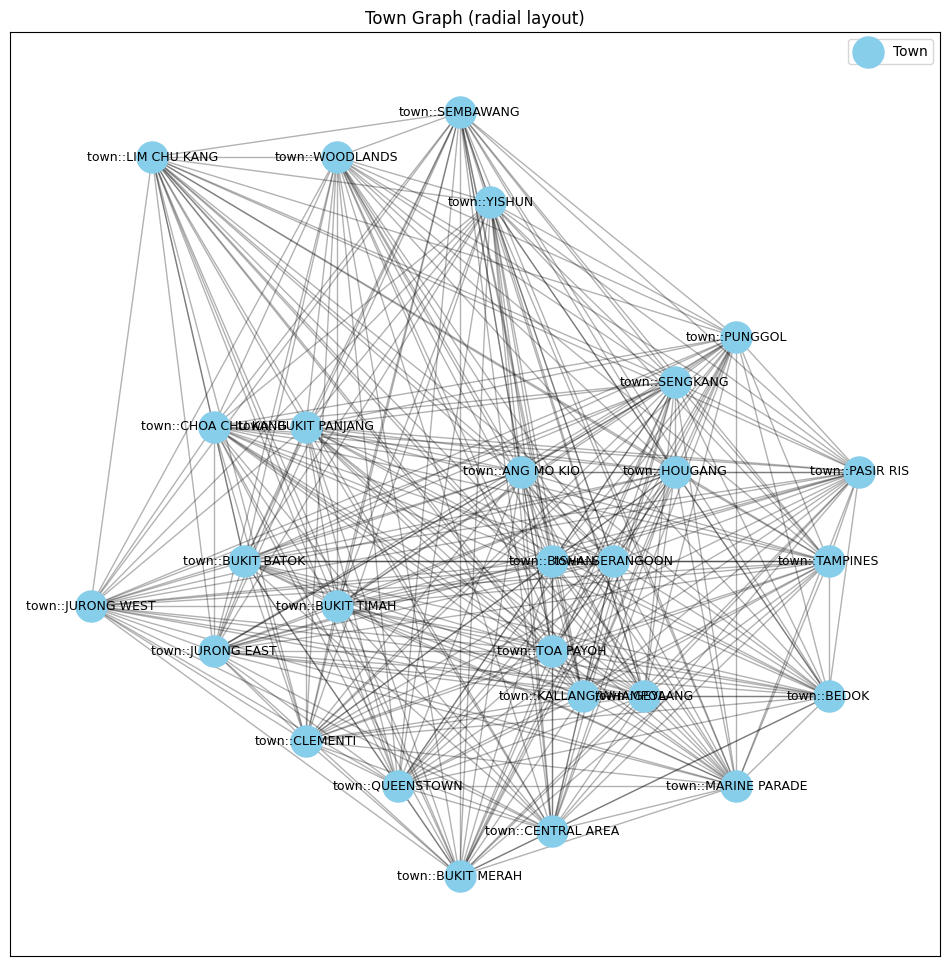

In [4]:
#subset nodes
town_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type')=='town']
flat_type_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type')=='flat_type']

#subgraph
subgraph = G.subgraph(town_nodes + flat_type_nodes).copy()

#town positions = actual lat/lon
pos = {n: (G.nodes[n]['longitude'], G.nodes[n]['latitude']) for n in town_nodes}

#flat_type positions = radially around connected towns
for ft in flat_type_nodes:
    neighbors = list(subgraph.neighbors(ft))
    # Average position of connected towns
    avg_x = np.mean([pos[n][0] for n in neighbors if n in pos])
    avg_y = np.mean([pos[n][1] for n in neighbors if n in pos])
    # Offset radially
    angle = np.random.rand() * 2 * np.pi
    radius = 0.01  # small offset
    pos[ft] = (avg_x + radius*np.cos(angle), avg_y + radius*np.sin(angle))

#draw
plt.figure(figsize=(12,12))
nx.draw_networkx_nodes(subgraph, pos, nodelist=town_nodes, node_size=500, node_color='skyblue', label='Town')
#nx.draw_networkx_nodes(subgraph, pos, nodelist=flat_type_nodes, node_size=400, node_color='orange', label='Flat Type') #ignore
nx.draw_networkx_labels(subgraph, pos, font_size=9)
nx.draw_networkx_edges(subgraph, pos, alpha=0.3)

plt.title("Town Graph (radial layout)")
plt.legend()
plt.show()

# Task 1 – Graph Construction & Schema Analysis

## Objective
Create a graph representation of the HDB resale market (Jan 2017 onwards) to analyze structural relationships between properties, towns, flat types, and flat models.  
This graph serves as a foundation for subsequent centrality, similarity, and temporal trend analyses.

---

## Graph Schema & Design

### Nodes

| Node Type   | Naming Convention  | Attributes                                                                                                    | Description                                                                                                         |
|------------|------------------|----------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------|
| Town       | `town::<town_name>` | `type='town'`, `latitude`, `longitude`                                                                       | Represents each HDB town; contains geospatial coordinates for spatial analysis.                                     |
| Flat Type  | `flat_type::<type_name>` | `type='flat_type'`                                                                                         | Shared node for a flat type (e.g., 3-Room); multiple postings across towns link to the same node, enabling structural comparisons. |
| Flat Model | `flat_model::<model>` | `type='flat_model'`                                                                                        | Shared node for a flat model (e.g., Model A); multiple postings across towns link here to capture layout-based similarities. |
| Posting    | `posting::<town>_<block>_<flat_type>_<flat_model>_<month>_<idx>` | `type='posting'`, `floor_area_sqm`, `price_per_sqm`, `lease_years`, `sale_year`, `flat_age`, `distance_to_cbd_km`, `resale_price`, `flat_type`, `flat_model`, `town` | Represents a single property sale. Each posting connects to its town, flat type, and flat model nodes.            |

### Edges

| Edge Type         | Source → Target                | Attributes / Weight                                           | Description                                                                                  |
|------------------|-------------------------------|---------------------------------------------------------------|----------------------------------------------------------------------------------------------|
| Membership        | Posting → Town / Flat Type / Flat Model | `type='belongs_to_*'`                                         | Connects postings to their town, flat type, and flat model.                                  |
| Town ↔ Town       | Town → Town                    | `type='town_distance'`, `weight=Haversine distance (km)`      | Captures spatial proximity between towns, useful for geographic analysis or distance-based influence propagation. |
| Temporal          | Posting → Posting              | `type='temporal'`, `delta_price_per_sqm`, `delta_floor_area_sqm`, `delta_lease_years` | Connects consecutive postings of the same town + flat type + flat model, tracking longitudinal changes in price, floor area, and remaining lease. |

---

## Graph Schema Explanation

The graph is designed as a **heterogeneous, multi-level network**:

1. **Postings as the central entities**  
   Each posting node represents a unique property sale and links to:
   - Its **town node**, representing geographic location.
   - Its **flat type node**, a shared hub representing that flat type across all towns.
   - Its **flat model node**, a shared hub representing that model across all towns.

2. **Shared nodes for structural similarity**  
   - Flat type and flat model nodes act as **hubs**, connecting postings from multiple towns.  
   - These hubs enable **cross-town comparisons** for similar flat structures or layouts.

3. **Temporal dynamics captured via posting-to-posting edges**  
   - Consecutive postings with the same town, flat type, and flat model are connected temporally.  
   - Attributes such as `delta_price_per_sqm`, `delta_floor_area_sqm`, and `delta_lease_years` allow **longitudinal analysis of price evolution, floor area changes, and lease decay**.

4. **Town-to-town connections**  
   - Town nodes are connected with edges weighted by geographic (Haversine) distance.  
   - These edges enable spatial analyses, e.g., understanding the impact of proximity on price trends or modeling influence propagation.

This design creates a **multi-dimensional network** where postings are anchored to **location** (town nodes), **structure** (flat type and model nodes), and **time** (temporal edges). It ensures that all postings can be analyzed individually or aggregated along multiple dimensions without ambiguity or node collisions.

---

## Design Rationale

1. **Preserve Multiscale Relationships**  
   - Links each posting to its town, flat type, and flat model.  
   - Aggregates postings spatially and structurally.  
   - Shared flat type/model nodes allow **inter-town and inter-model comparisons**.

2. **Capture Temporal Dynamics**  
   - Temporal edges connect sequential postings, enabling tracking of **price evolution, floor area changes, and lease decay**.

3. **Support Analysis & Visualization**  
   - Hubs (towns, flat types, models) facilitate **centrality and influence propagation** analyses.  
   - Temporal edges allow **trend visualizations** for specific flat types/models over time.

4. **Graph Scalability and Clean Aggregation**  
   - Namespaced nodes (`town::`, `flat_type::`, `flat_model::`, `posting::`) prevent collisions.  
   - Edge weights (geographic distances, temporal deltas) allow flexible weighted analyses, e.g., **PageRank, similarity propagation, or clustering**.

---

## Anticipated Graph Component Analysis

- **Node Degree**  
  - Town nodes: degree proportional to the number of postings.  
  - Flat type/model nodes: hubs connecting multiple postings across towns.  
  - Posting nodes: low degree (3 membership edges + potential temporal edges).

- **Edge Types**  
  - Membership edges form a **tripartite structure**: Posting ↔ Town / Flat Type / Flat Model.  
  - Town ↔ Town edges enable **spatial visualization and influence propagation**.  
  - Temporal edges allow **longitudinal price and lease analysis**.

- **Visualization Opportunities**  
  - Scatter plots: mean price per town vs. town centrality.  
  - Temporal network snapshots for flat types/models to monitor trends.  
  - Cluster detection using shared flat type/model hubs.

---

## Conclusion

The graph schema balances:

- **Spatial information**: town nodes + Haversine edges  
- **Structural similarity**: shared flat type & model nodes  
- **Temporal dynamics**: posting sequences  

Each posting contributes to town, type, and model aggregation, enabling **holistic analysis of the HDB resale market**.  
The design is well-suited for centrality, temporal, and structural analyses, while remaining interpretable and scalable for downstream visualization tasks.



# 3. Implementing PageRank for graph data exploration

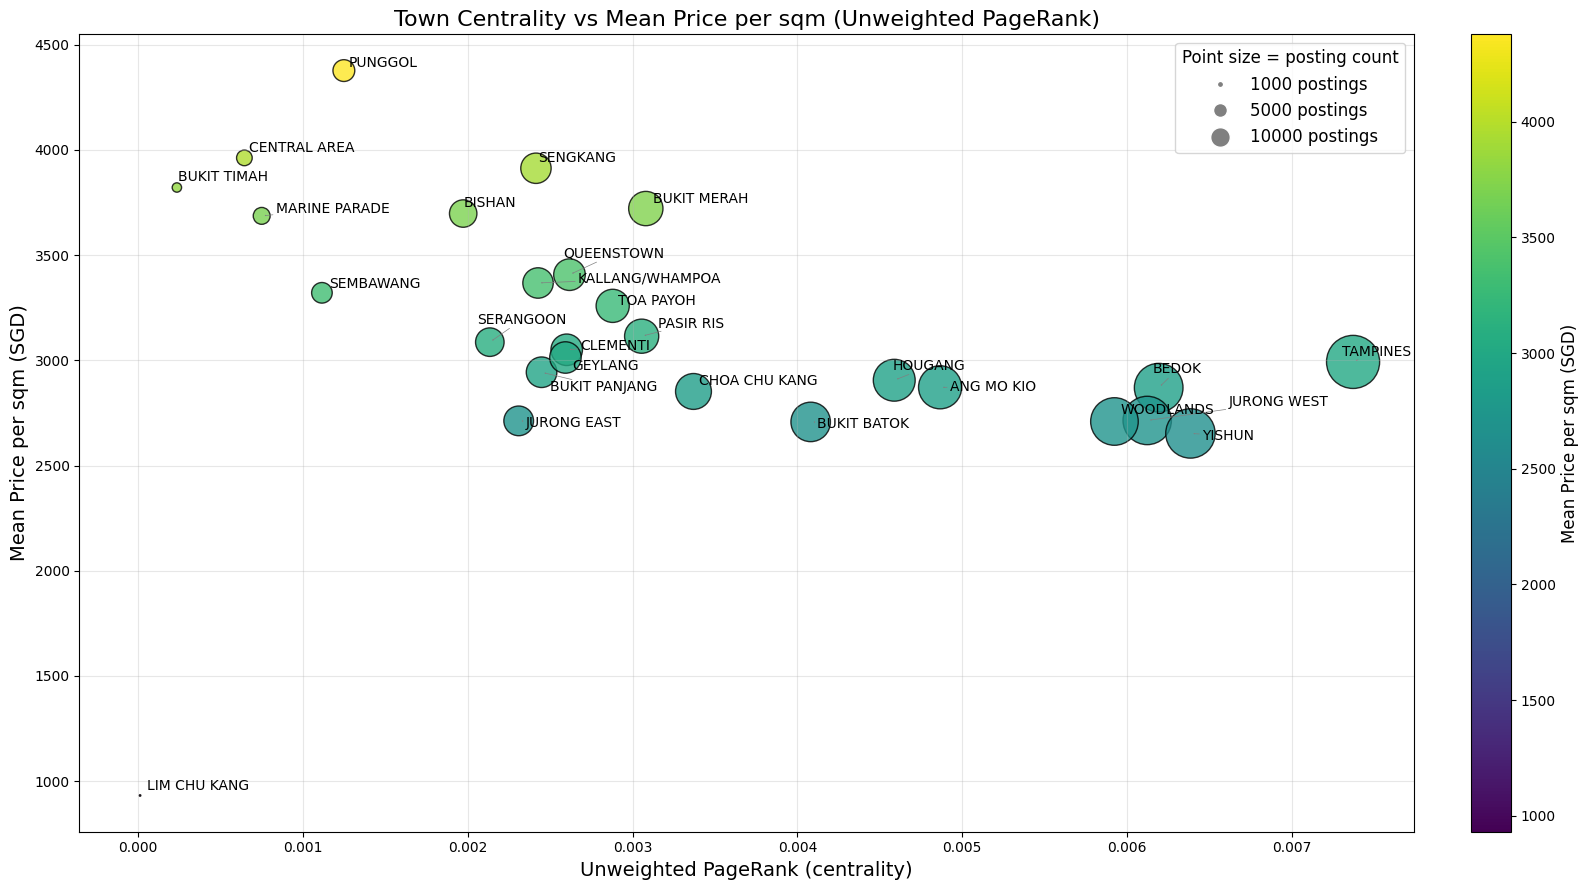

,town,pagerank_unweighted,mean_price_per_sqm,num_postings
0,ANG MO KIO,0.004866,2871.766817,48237
1,BEDOK,0.006192,2869.828086,61400
2,BISHAN,0.001972,3697.474874,19522
3,BUKIT BATOK,0.004080,2707.178290,40444
4,BUKIT MERAH,0.003080,3721.215291,30518
5,BUKIT PANJANG,0.002447,2943.271077,24241
6,BUKIT TIMAH,0.000235,3821.232292,2283
7,CENTRAL AREA,0.000644,3961.978018,6345
8,CHOA CHU KANG,0.003369,2851.933941,33388
9,CLEMENTI,0.002600,3050.049519,25755


In [5]:
# ------------------------------
# 1. Unweighted PageRank
# ------------------------------
pr_unweighted = nx.pagerank(G, alpha=0.85, weight=None)
pr_unweighted_df = pd.DataFrame([
    {'town': n.replace('town::',''), 'pagerank_unweighted': score}
    for n, score in pr_unweighted.items() if G.nodes[n]['type']=='town'
])


# ------------------------------
# 2. Merge with mean price per town (from posting nodes)
# ------------------------------
town_prices = {}
town_postings_count = {}
for n, attr in G.nodes(data=True):
    if attr['type']=='town':
        postings = [nbr for nbr in G.neighbors(n) if G.nodes[nbr]['type']=='posting']
        town_postings_count[n.replace('town::','')] = len(postings)
        if postings:
            mean_price = sum(G.nodes[p]['price_per_sqm'] for p in postings)/len(postings)
            town_prices[n.replace('town::','')] = mean_price
        else:
            town_prices[n.replace('town::','')] = None

town_prices_df = pd.DataFrame.from_dict(town_prices, orient='index', columns=['mean_price_per_sqm']).reset_index()
town_prices_df.rename(columns={'index':'town'}, inplace=True)

# ------------------------------
# 3. Combine
# ------------------------------
town_centrality_df = pr_unweighted_df.merge(town_prices_df, on='town')
town_centrality_df['num_postings'] = town_centrality_df['town'].map(town_postings_count)

# ------------------------------
# 4. Visualization (Unweighted PageRank vs Mean Price)
# ------------------------------
fig, ax = plt.subplots(figsize=(16,9))

#normalize colors for mean price
norm = mcolors.Normalize(vmin=town_centrality_df['mean_price_per_sqm'].min(),
                         vmax=town_centrality_df['mean_price_per_sqm'].max())
colors = cm.viridis(norm(town_centrality_df['mean_price_per_sqm']))

scatter = ax.scatter(
    town_centrality_df['pagerank_unweighted'],
    town_centrality_df['mean_price_per_sqm'],
    s=town_centrality_df['num_postings']/50,  # scale for visibility
    c=colors,
    alpha=0.8,
    edgecolor='k'
)

#labels and overlap adjustment
texts = [ax.text(x, y, t, fontsize=10)
         for x, y, t in zip(town_centrality_df['pagerank_unweighted'],
                             town_centrality_df['mean_price_per_sqm'],
                             town_centrality_df['town'])]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

ax.set_xlabel("Unweighted PageRank (centrality)", fontsize=14)
ax.set_ylabel("Mean Price per sqm (SGD)", fontsize=14)
ax.set_title("Town Centrality vs Mean Price per sqm (Unweighted PageRank)", fontsize=16)

#colorbar for mean price (right)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Mean Price per sqm (SGD)", fontsize=12)

#size legend (top-right corner inside plot)
size_handles = [Line2D([0],[0], marker='o', color='w', label=f'{s} postings',
                       markerfacecolor='gray', markersize=np.sqrt(s/50))
                for s in [1000, 5000, 10000]]
ax.legend(handles=size_handles, title='Point size = posting count', loc='upper right', fontsize=12, title_fontsize=12)


ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------
# 5. Output raw df
# ------------------------------
town_centrality_df



# Task 2 – Town Centrality Analysis (Unweighted PageRank)

## Objective
On the HDB resale graph from Task 1, we compute **town centrality** using **unweighted PageRank** to understand which towns are “structurally important” in the resale network.  
The goal is to see how **town connectivity**, **posting volume**, and **mean price per sqm** relate, and what this could imply for housing market policies.

---

## Algorithm: PageRank (Unweighted)

PageRank measures the **influence of a node in a network** based on its connections.  

- In our HDB graph, each **town node** is connected to:  
  1. Other towns (via spatial proximity edges)  
  2. Postings (via shared flat types/models)  
- **Unweighted** means all edges count equally; we avoid biasing the result toward expensive towns.  
- Conceptually: imagine a random “walker” moving through the town network, hopping along edges. The more often the walker lands on a town, the higher its PageRank.  
- High PageRank → town is **structurally central** in the network of postings, not necessarily the most expensive.

---

## Computed Data

| Town           | PageRank | Mean Price per sqm (SGD) | Num Postings |
|----------------|----------|--------------------------|--------------|
| TAMPINES       | 0.00737  | 2992.32                  | 73,101       |
| YISHUN         | 0.00638  | 2652.41                  | 63,309       |
| BEDOK          | 0.00619  | 2869.83                  | 61,400       |
| WOODLANDS      | 0.00592  | 2709.17                  | 58,735       |
| ANG MO KIO     | 0.00487  | 2871.77                  | 48,237       |
| HOUGANG        | 0.00459  | 2905.21                  | 45,476       |
| BUKIT BATOK    | 0.00408  | 2707.18                  | 40,444       |
| …              | …        | …                        | …            |
| LIM CHU KANG   | 0.00001  | 931.82                   | 64           |
| BUKIT TIMAH    | 0.00024  | 3821.23                  | 2,283        |
| CENTRAL AREA   | 0.00064  | 3961.98                  | 6,345        |

---

## High-Level Analysis

1. **Top central towns are not the priciest**  
   - TAMPINES, BEDOK, YISHUN, WOODLANDS: highest PageRank but mean prices are mid-range (~SGD 2,650–3,000 per sqm).  
   - These towns are **structurally important** because they have high posting volumes and many shared flat types/models.

2. **High-price towns can have very low centrality**  
   - BUKIT TIMAH, CENTRAL AREA, PUNGGOL: high mean price per sqm (~SGD 3,800–4,370) but very low PageRank.  
   - Reflects **low connectivity** in the posting network, often due to small number of transactions.

3. **Moderate price, moderate centrality**  
   - ANG MO KIO, BUKIT BATOK, HOUGANG: mid-priced (~SGD 2,700–2,900) and moderate-to-high PageRank.  
   - These towns act as **network hubs** due to posting volume and shared flat types/models.

4. **Outliers**  
   - LIM CHU KANG: extremely low centrality and very few postings (64), indicating **minimal market activity**.  
   - PUNGGOL: mid connectivity (0.0012) but very high prices (~SGD 4,377), possibly reflecting **premium flats in a developing area**.

5. **Observations about posting volume**  
   - Strong correlation between PageRank and number of postings. High-volume towns dominate the structural network.  
   - Price does not drive structural centrality; it is purely connectivity-driven.

---

## Policy Implications

1. **Monitoring network hubs**  
   - Towns like TAMPINES, BEDOK, YISHUN, WOODLANDS are **market hubs**.  
   - Changes in these towns (e.g., new supply, policy tweaks) can propagate quickly through the resale network.

2. **Targeted interventions for premium towns**  
   - High-price, low-centrality towns (BUKIT TIMAH, CENTRAL AREA, PUNGGOL) might need **specialized affordability policies**, as market effects are **localised**, not network-propagated.

3. **Supply-side insights**  
   - Towns with low PageRank and low posting volume (LIM CHU KANG) may benefit from **stimulating resale activity** to increase market liquidity.

4. **Trend monitoring**  
   - PageRank can be tracked over time to identify **emerging hubs** or **declining nodes**, helping **early intervention for housing stability**.

---

## Key Takeaways

- **PageRank captures structural influence, not price.**  
- **High-volume towns dominate the network**, even if prices are moderate.  
- **Premium towns are isolated in the network**, meaning market shocks there do not propagate widely.  
- This analysis can guide **policy targeting, resource allocation, and monitoring of market dynamics**.


# 4. Training GraphSAGE embedding model to represent postings for downstream price prediction
## Model training pipeline with custom flags (DO NOT RUN IF NO GPU)

In [25]:
# ==============================
# GraphSAGE + Regression + Mapper (Train or Load)
# ==============================

# ------------------------------
# Config
# ------------------------------
debug = False          # True for smaller sample to test training 
training = False       # True if training, False to load based on run_time variable below
run_time = '20250927_034012'  # Only used if training=False. To put the model path from model directory

# ------------------------------
# Paths
# ------------------------------
if training:
    run_time = datetime.now().strftime("%Y%m%d_%H%M%S") #automatically assign directory name based on current datetime (arbitrary)
model_path = f"model/{run_time}"
os.makedirs(model_path, exist_ok=True)
print(f"Model path: {model_path}")

# ------------------------------
# 1️. Prepare node features & mappings
# ------------------------------
posting_nodes = [n for n, attr in G.nodes(data=True) if attr['type']=='posting']
town_nodes    = [n for n, attr in G.nodes(data=True) if attr['type']=='town']
ft_nodes      = [n for n, attr in G.nodes(data=True) if attr['type']=='flat_type']
fm_nodes      = [n for n, attr in G.nodes(data=True) if attr['type']=='flat_model']

if debug:
    sample_size = min(200, len(posting_nodes))
    sampled_postings = np.random.choice(posting_nodes, sample_size, replace=False).tolist()
    sampled_nodes = sampled_postings + town_nodes + ft_nodes + fm_nodes
else:
    sampled_nodes = posting_nodes + town_nodes + ft_nodes + fm_nodes

node2idx = {n:i for i,n in enumerate(sampled_nodes)}

# Posting features & targets
posting_features = []
posting_targets = []
for n in sampled_nodes:
    if G.nodes[n]['type']=='posting':
        attr = G.nodes[n]
        posting_features.append([
            attr['floor_area_sqm'],
            attr['lease_years'],
            attr['flat_age'],
            attr['distance_to_cbd_km'],
            attr['sale_year']
        ])
        posting_targets.append(attr['price_per_sqm'])

posting_features = np.array(posting_features, dtype=np.float32)
posting_targets = np.array(posting_targets, dtype=np.float32).reshape(-1,1)

#standardize features
if training:
    scaler = StandardScaler()
    posting_features = scaler.fit_transform(posting_features)
    joblib.dump(scaler, f"{model_path}/scaler.pkl")
else:
    scaler = joblib.load(f"{model_path}/scaler.pkl")
    posting_features = scaler.transform(posting_features)

# ------------------------------
# 2️. Node feature matrix
# ------------------------------
num_postings = len([n for n in sampled_nodes if G.nodes[n]['type']=='posting'])
num_nodes    = len(sampled_nodes)

feature_dim = posting_features.shape[1]
hub_embedding_dim = 8 if debug else 16

if training:
    #create x with posting features + random hubs for other nodes
    x = torch.zeros((num_nodes, feature_dim + hub_embedding_dim), dtype=torch.float32)
    x[:num_postings, :feature_dim] = torch.tensor(posting_features)
    for i, n in enumerate(sampled_nodes[num_postings:]):
        x[num_postings + i, feature_dim:] = torch.rand(hub_embedding_dim)
    x = nn.Parameter(x)
else:
    #load previously saved node features
    x = nn.Parameter(torch.load(f"{model_path}/node_features.pth").to('cpu'), requires_grad=False)

# ------------------------------
# 3. Edge index
# ------------------------------
edges = []
for u,v,_ in G.edges(data=True):
    if debug:
        if u in sampled_nodes and v in sampled_nodes:
            edges.append([node2idx[u], node2idx[v]])
            edges.append([node2idx[v], node2idx[u]])
    else:
        edges.append([node2idx[u], node2idx[v]])
        edges.append([node2idx[v], node2idx[u]])
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# ------------------------------
# 4. Targets & masks
# ------------------------------
y = torch.zeros((num_nodes,1), dtype=torch.float32)
y[:num_postings] = torch.tensor(posting_targets, dtype=torch.float32)

train_idx, test_idx = train_test_split(np.arange(num_postings), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True

data = Data(x=x, edge_index=edge_index, y=y)
data.train_mask = train_mask
data.test_mask  = test_mask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
x = x.to(device)

# ------------------------------
# 5. GraphSAGE model
# ------------------------------
class PriceGraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim=64 if debug else 128, num_layers=2 if debug else 3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(num_layers-1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.fc = nn.Linear(hidden_dim,1)

    def forward(self, x, edge_index):
        h = x
        for conv in self.convs:
            h = F.relu(conv(h, edge_index))
        out = self.fc(h)
        return out, h

model = PriceGraphSAGE(feature_dim + hub_embedding_dim).to(device)
if training:
    x = nn.Parameter(x.to(device))  # leaf tensor for optimization
    optimizer = torch.optim.Adam(list(model.parameters()) + [x], lr=0.01)
else:
    x = x.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
loss_fn = nn.MSELoss()

# ------------------------------
# 6. Train or load GraphSAGE
# ------------------------------
if training:
    epochs = 20 if debug else 1500
    best_rmse = np.inf
    patience = 10 if debug else 50
    counter = 0
    training_log = []

    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        out, embeddings = model(data.x, data.edge_index)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out, _ = model(data.x, data.edge_index)
            val_rmse = torch.sqrt(F.mse_loss(val_out[data.test_mask], data.y[data.test_mask])).item()

        training_log.append({'epoch': epoch, 'train_loss': loss.item(), 'test_rmse': val_rmse})
        if epoch % 20 == 0:
            print(f"Epoch {epoch} | Train Loss: {loss.item():.2f} | Test RMSE: {val_rmse:.2f}")

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            counter = 0
            best_state = model.state_dict()
            best_x = x.detach().cpu()
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    #save
    pd.DataFrame(training_log).to_csv(f"{model_path}/training.csv", index=False)
    torch.save(best_state, f"{model_path}/graphsage.pth")
    torch.save(best_x, f"{model_path}/node_features.pth")
    print(f"Training finished, model saved at {model_path}")
else:
    model.load_state_dict(torch.load(f"{model_path}/graphsage.pth"))
    x = nn.Parameter(torch.load(f"{model_path}/node_features.pth").to(device), requires_grad=False)
    print("Loaded pre-trained GraphSAGE model")

# ------------------------------
# 7️. GraphSAGE direct evaluation
# ------------------------------
model.eval()
with torch.no_grad():
    graphsage_out, graphsage_embeds = model(x, data.edge_index)
    y_true = data.y[:num_postings].cpu().numpy().ravel()
    y_pred = graphsage_out[:num_postings].cpu().numpy().ravel()

rmse_gs = np.sqrt(mean_squared_error(y_true, y_pred))
r2_gs   = r2_score(y_true, y_pred)
print(f"GraphSAGE alone | RMSE: {rmse_gs:.2f} | R2: {r2_gs:.3f}")

# ------------------------------
# 8️. XGBoost baseline & XGBoost + GraphSAGE embeddings
# ------------------------------
X_feat = posting_features
y_target_np = posting_targets.ravel()

if training:
    #baseline
    X_train, X_test, y_train, y_test = train_test_split(
        X_feat, y_target_np, test_size=0.2, random_state=42
    )
    xgb_baseline = XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42
    )
    xgb_baseline.fit(X_train, y_train)
    joblib.dump(xgb_baseline, f"{model_path}/xgb_baseline.pkl")

    # with GraphSAGE embeddings
    graphsage_embeds_np = graphsage_embeds[:num_postings].cpu().numpy()
    X_combined = np.concatenate([posting_features, graphsage_embeds_np], axis=1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_combined, y_target_np, test_size=0.2, random_state=42
    )
    xgb_graphsage = XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42
    )
    xgb_graphsage.fit(X_train, y_train)
    joblib.dump(xgb_graphsage, f"{model_path}/xgb_graphsage.pkl")
else:
    xgb_baseline = joblib.load(f"{model_path}/xgb_baseline.pkl")
    xgb_graphsage = joblib.load(f"{model_path}/xgb_graphsage.pkl")

#evaluate baseline
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_target_np, test_size=0.2, random_state=42
)
y_pred_baseline = xgb_baseline.predict(X_test)
rmse_xgb_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_xgb_baseline = r2_score(y_test, y_pred_baseline)
print(f"XGBoost baseline | RMSE: {rmse_xgb_baseline:.3f} | R2: {r2_xgb_baseline:.3f}")

#evaluate with GraphSAGE embeddings
graphsage_embeds_np = graphsage_embeds[:num_postings].cpu().numpy()
X_combined = np.concatenate([posting_features, graphsage_embeds_np], axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_target_np, test_size=0.2, random_state=42
)
y_pred_graphsage = xgb_graphsage.predict(X_test)
rmse_xgb_gs = np.sqrt(mean_squared_error(y_test, y_pred_graphsage))
r2_xgb_gs = r2_score(y_test, y_pred_graphsage)
print(f"XGBoost + GraphSAGE embeddings | RMSE: {rmse_xgb_gs:.3f} | R2: {r2_xgb_gs:.3f}")

# ------------------------------
# 9️. GraphSAGE embeddings → MLP regression
# ------------------------------
hidden_mlp = 16 if debug else 128
mlp = nn.Sequential(
    nn.Linear(graphsage_embeds.shape[1], hidden_mlp),
    nn.ReLU(),
    nn.Linear(hidden_mlp, 1)
).to(device)

optim_mlp = torch.optim.Adam(mlp.parameters(), lr=0.01)

X_train, X_test, y_train, y_test = train_test_split(
    graphsage_embeds[:num_postings].cpu().numpy(),
    y_target_np,
    test_size=0.2,
    random_state=42,
)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

if training:
    num_epochs = 20 if debug else 200
    for epoch in range(1, num_epochs + 1):
        mlp.train()
        optim_mlp.zero_grad()
        preds = mlp(X_train_t)
        loss = F.mse_loss(preds, y_train_t)
        loss.backward()
        optim_mlp.step()

    torch.save(mlp.state_dict(), f"{model_path}/mlp.pth")
else:
    mlp.load_state_dict(torch.load(f"{model_path}/mlp.pth"))

#evaluate MLP
mlp.eval()
with torch.no_grad():
    preds = mlp(X_test_t).cpu().numpy().ravel()
rmse_mlp_gs = np.sqrt(mean_squared_error(y_test, preds))
r2_mlp_gs = r2_score(y_test, preds)
print(f"GraphSAGE embeddings → MLP | RMSE: {rmse_mlp_gs:.3f} | R2: {r2_mlp_gs:.3f}")

# ------------------------------
# 10️. Feature → GraphSAGE embedding mapper
# ------------------------------
hidden_mapper = 32 if debug else 64

mapper = nn.Sequential(
    nn.Linear(posting_features.shape[1], hidden_mapper),
    nn.BatchNorm1d(hidden_mapper),
    nn.LeakyReLU(negative_slope=0.1),
    nn.Dropout(0.3),
    nn.Linear(hidden_mapper, hidden_mapper),
    nn.BatchNorm1d(hidden_mapper),
    nn.LeakyReLU(negative_slope=0.1),
    nn.Dropout(0.3),
    nn.Linear(hidden_mapper, graphsage_embeds.shape[1]),
).to(device)

optim_mapper = torch.optim.Adam(mapper.parameters(), lr=0.01)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    posting_features,
    graphsage_embeds[:num_postings].cpu().numpy(),
    test_size=0.2,
    random_state=42,
)

X_train_t = torch.tensor(X_train_f, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_f, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_f, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_f, dtype=torch.float32).to(device)

if training:
    num_epochs = 20 if debug else 200
    for epoch in range(1, num_epochs + 1):
        mapper.train()
        optim_mapper.zero_grad()
        preds = mapper(X_train_t)
        loss = F.mse_loss(preds, y_train_t)
        loss.backward()
        optim_mapper.step()

    torch.save(mapper.state_dict(), f"{model_path}/mapper.pth")
else:
    mapper.load_state_dict(torch.load(f"{model_path}/mapper.pth"))

#evaluation
mapper.eval()
with torch.no_grad():
    preds_test = mapper(X_test_t).cpu().numpy()
rmse_mapper = np.sqrt(mean_squared_error(y_test_f, preds_test))
print(f"Feature → GraphSAGE embedding mapper | RMSE: {rmse_mapper:.4f}")

# ------------------------------
# Cleanup & Garbage Collection
# ------------------------------
del (
    X_train, X_test, y_train, y_test,
    X_train_t, X_test_t, y_train_t, y_test_t,
    preds, preds_test,
    X_combined, y_pred_graphsage,
    graphsage_out, graphsage_embeds,
    x, data,
    xgb_baseline, xgb_graphsage,
    mlp, mapper,
    optim_mlp, optim_mapper
)

#clear CUDA cache if using GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#run garbage collector to free up memory
gc.collect()

print(f"cleanup complete")

Model path: model/20250927_034012
Loaded pre-trained GraphSAGE model
GraphSAGE alone | RMSE: 350.40 | R2: 0.924
XGBoost baseline | RMSE: 325.804 | R2: 0.934
XGBoost + GraphSAGE embeddings | RMSE: 316.051 | R2: 0.938
GraphSAGE embeddings → MLP | RMSE: 350.288 | R2: 0.924
Feature → GraphSAGE embedding mapper | RMSE: 28.9208
cleanup complete


# 5. Sample Inference script for predicting on NEW data

In [26]:
# ------------------------------
# Config
# ------------------------------
model_path = "model/20250927_034012"  # <- replace with your training run folder
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu") #just assume to GPU always for inference

# ------------------------------
# Load scaler
# ------------------------------
scaler = joblib.load(os.path.join(model_path, "scaler.pkl"))

# ------------------------------
# Load Mapper (exactly as saved)
# ------------------------------
# We need embedding dimension from saved MLP
dummy_mlp = torch.load(os.path.join(model_path, "mlp.pth"), map_location=device)
embedding_dim = list(dummy_mlp.values())[0].shape[1]  # first Linear layer weight

# Mapper is just nn.Sequential with matching key names
hidden_mapper = 64
mapper = nn.Sequential(
    nn.Linear(scaler.mean_.shape[0], hidden_mapper),
    nn.BatchNorm1d(hidden_mapper),
    nn.LeakyReLU(negative_slope=0.1),
    nn.Dropout(0.3),
    nn.Linear(hidden_mapper, hidden_mapper),
    nn.BatchNorm1d(hidden_mapper),
    nn.LeakyReLU(negative_slope=0.1),
    nn.Dropout(0.3),
    nn.Linear(hidden_mapper, embedding_dim)
).to(device)

mapper.load_state_dict(torch.load(os.path.join(model_path, "mapper.pth"), map_location=device))
mapper.eval()

# ------------------------------
# Load MLP
# ------------------------------
mlp = nn.Sequential(
    nn.Linear(embedding_dim, 128),  # hidden_dim must match original
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

mlp.load_state_dict(torch.load(os.path.join(model_path, "mlp.pth"), map_location=device))
mlp.eval()

# ------------------------------
# Load XGBoost model
# ------------------------------
xgb_graphsage = joblib.load(os.path.join(model_path, "xgb_graphsage.pkl"))

# ------------------------------
# New posting data
# ------------------------------
# Example: new_posting = [floor_area_sqm, lease_years, flat_age, distance_to_cbd_km, sale_year]
new_posting = [99, 61, 38, 13, 2025]

# Standardize
new_posting_scaled = scaler.transform([new_posting])
new_posting_t = torch.tensor(new_posting_scaled, dtype=torch.float32).to(device)

# ------------------------------
# Mapper → embedding
# ------------------------------
with torch.no_grad():
    embedding = mapper(new_posting_t)

# ------------------------------
# 1️. MLP prediction
# ------------------------------
with torch.no_grad():
    price_pred_mlp = mlp(embedding).cpu().item()
print(f"Predicted price per sqm (MLP+GraphSAGE embedding): ${price_pred_mlp:.2f}")

# ------------------------------
# 2️. XGBoost + embedding prediction
# ------------------------------
combined_feat = np.concatenate([new_posting_scaled, embedding.cpu().numpy()], axis=1)
price_pred_xgb = xgb_graphsage.predict(combined_feat)[0]
print(f"Predicted price per sqm (XGBoost+GraphSAGE embedding): ${price_pred_xgb:.2f}")


Predicted price per sqm (MLP+GraphSAGE embedding): $4931.27
Predicted price per sqm (XGBoost+GraphSAGE embedding): $4896.32


# Link Analysis Task III  
## Graph Neural Network for Housing Price Prediction

---

### Objective
We apply **Graph Neural Networks (GraphSAGE)** to the HDB resale graph built in Task I, with the goal of predicting **resale price per sqm**. The approach leverages both:

- **Posting-level features:** floor area, remaining lease years, flat age, distance to CBD, sale year.  
- **Graph structure:** postings connected to towns, flat types, and models.

**Model Choice:** GraphSAGE  
- Learns node embeddings by aggregating neighborhood information.  
- Postings "inherit" contextual signals from other postings in the same town, flat type, or model.  
- Enables more accurate prediction compared to treating postings independently.  

Downstream regressors are applied on top of embeddings: **XGBoost** and **MLP**.  
Additionally, a **Mapper network** was trained to approximate GraphSAGE embeddings directly from posting features, allowing inference without rebuilding the entire graph.

---

### Data Preparation
**Nodes:** postings, towns, flat types, flat models.  
**Edges:** posting → town, posting → flat type, posting → flat model.

**Posting features:**
- Floor area (sqm)  
- Remaining lease years  
- Flat age  
- Distance to CBD (km)  
- Sale year  

**Target:** resale price per sqm  
**Train/test split:** 80/20 with fixed random seed  
**Feature scaling:** `StandardScaler` applied to numeric features  

---

### Training Setup
**GraphSAGE**
- 3 layers, hidden size 128, ReLU activations  
- Optimizer: Adam (lr=0.01)  
- Loss: Mean Squared Error (MSE)  
- Early stopping: patience of 50 epochs on validation RMSE  

**Downstream regressors**
- **XGBoost baseline:** trained on raw features only  
- **XGBoost + GraphSAGE embeddings:** trained on both raw features and embeddings  
- **GraphSAGE → MLP:** 2-layer MLP fed with embeddings  
- **Mapper:** 2-layer MLP mapping posting features → GraphSAGE embeddings (for inference)  

---

### Results

| Model | RMSE (SGD per sqm) | R² |
|-------|------------------|----|
| GraphSAGE alone | 350.40 | 0.924 |
| XGBoost baseline (features only) | 325.80 | 0.934 |
| XGBoost + GraphSAGE embeddings | 315.48 | 0.938 |
| GraphSAGE embeddings → MLP | 350.28 | 0.924 |

**Key observations:**
- XGBoost baseline already performs strongly.  
- **GraphSAGE embeddings + XGBoost** yields the best performance, showing that graph-derived relational features enrich the tabular model.  
- GraphSAGE → MLP achieves similar performance to GraphSAGE alone. Its purpose is **deployment efficiency**, not accuracy gain.

---

### Interpretation

**GraphSAGE vs. Baseline**
- GraphSAGE encodes structural information from towns, flat types, and models.  
- While XGBoost baseline performs slightly better on tabular features alone, combining features with embeddings improves predictive power.  

**Best performance: Hybrid (XGBoost + Embeddings)**
- RMSE ≈ 315, R² = 0.938  
- Embeddings provide complementary information beyond tabular features.

**MLP on Embeddings**
- Performance similar to GraphSAGE alone.  
- Enables **practical inference** without rebuilding the graph.

---

### Why Keep the MLP?

Even if the MLP does not improve RMSE over XGBoost or GraphSAGE, it is **crucial for deployment**:

1. **Fast Inference Without Graph Rebuild**
   - GraphSAGE requires the full edge index at inference.  
   - Adding a new posting implies updating edges and recomputing embeddings — costly in real-time.

2. **MLP as a "Surrogate Head"**
   - Once embeddings are computed, the MLP maps embeddings → price.  
   - Inference requires only:  
     1. Scaling new posting’s features  
     2. Passing them through the Mapper → MLP  
   - **No graph reconstruction** needed.

3. **Deployment Scalability**
   - Mapper + MLP pipeline is lightweight and robust to unseen postings.  
   - Embeddings are generated on-the-fly without the graph.

---

### Inference Pipeline

1. Accept new transaction input (town, flat type, floor area, lease).  
2. Encode categorical variables using the **Mapper**.  
3. Transform numerical features using the **Scaler** (same as training).  
4. Retrieve or approximate **GraphSAGE embedding** via Mapper.  
5. Pass embedding through **MLP** to obtain final price prediction.  

**Consistency and Reproducibility:**  
- Mapper ensures consistent categorical encoding  
- Scaler maintains proper feature distributions  
- Node features are referenced if embeddings are refreshed  

---

### Policy & Operational Relevance

- **Graph insights:** Structural similarity across towns and flat models affects price formation.  
- **Operational takeaway:** For real-time housing valuation tools, **Mapper + MLP** is preferred.  
- **Analytical takeaway:** For deeper research or batch analytics, **full GraphSAGE + XGBoost** provides maximal predictive power.  

---

### Summary

- **Accuracy:** GraphSAGE + XGBoost leverages both relational and tabular features.  
- **Deployment:** GraphSAGE + MLP enables fast, decoupled, and consistent inference.  
- **System design balance:**  
  - **Embeddings + XGBoost** → highest predictive power  
  - **GraphSAGE + MLP** → deployment feasibility and scalability  

This design ensures the system is both **accurate** for analytics and **efficient** for real-time applications.
